# understanding data and removing duplicates

In [22]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
data_messy = pd.read_csv('student_performance_research.csv')
data_clean = pd.read_csv('student_performance_CLEAN.csv')
data_raw = pd.read_csv("student_performance_research.csv")
data_messy.info()
print(data_messy.duplicated().sum())
data_messy.drop_duplicates(inplace=True)

data_messy['school_type'] = data_messy['school_type'].str.lower()
data_messy['internet_quality'] = data_messy['internet_quality'].str.lower()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               5050 non-null   object 
 1   study_hours_per_week     5050 non-null   float64
 2   sleep_hours_per_night    4805 non-null   float64
 3   attendance_pct           5050 non-null   float64
 4   previous_gpa             4792 non-null   float64
 5   screen_time_hrs_per_day  4842 non-null   float64
 6   has_tutoring             5050 non-null   int64  
 7   part_time_job            5050 non-null   int64  
 8   internet_quality         5033 non-null   object 
 9   school_type              5050 non-null   object 
 10  parent_education         5050 non-null   object 
 11  commute_minutes          5050 non-null   int64  
 12  extracurricular_count    5050 non-null   int64  
 13  favorite_color           5050 non-null   object 
 14  id_is_even              

# Setting statistical rules for our data set

In [23]:
data_messy.loc[data_messy["study_hours_per_week"] >= 75, "study_hours_per_week"] = np.nan
data_messy.loc[data_messy["attendance_pct"] > 100, "attendance_pct"] = np.nan
data_messy.loc[data_messy["sleep_hours_per_night"] < 0, "sleep_hours_per_night"] = np.nan
data_messy.info()



<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               5000 non-null   object 
 1   study_hours_per_week     4990 non-null   float64
 2   sleep_hours_per_night    4752 non-null   float64
 3   attendance_pct           4992 non-null   float64
 4   previous_gpa             4746 non-null   float64
 5   screen_time_hrs_per_day  4794 non-null   float64
 6   has_tutoring             5000 non-null   int64  
 7   part_time_job            5000 non-null   int64  
 8   internet_quality         4984 non-null   object 
 9   school_type              5000 non-null   object 
 10  parent_education         5000 non-null   object 
 11  commute_minutes          5000 non-null   int64  
 12  extracurricular_count    5000 non-null   int64  
 13  favorite_color           5000 non-null   object 
 14  id_is_even               5000

# Delaing with missing data values

In [24]:
missing_sleep = data_messy["sleep_hours_per_night"].isna()
print(data_messy.groupby(missing_sleep)["attendance_pct"].mean())

for col in ["sleep_hours_per_night", "previous_gpa", "screen_time_hrs_per_day","study_hours_per_week"]:
  data_messy[col] = data_messy[col].fillna(data_messy[col].median())
data_messy["internet_quality"] = data_messy["internet_quality"].fillna("none")
data_messy["attendance_pct"] = data_messy["attendance_pct"].fillna(data_messy["attendance_pct"].median())

print(data_messy.isna().sum())   # verify: every count now 0

sleep_hours_per_night
False    81.836396
True     75.335628
Name: attendance_pct, dtype: float64
student_id                 0
study_hours_per_week       0
sleep_hours_per_night      0
attendance_pct             0
previous_gpa               0
screen_time_hrs_per_day    0
has_tutoring               0
part_time_job              0
internet_quality           0
school_type                0
parent_education           0
commute_minutes            0
extracurricular_count      0
favorite_color             0
id_is_even                 0
final_exam_score           0
passed                     0
dtype: int64


# Visualising our data

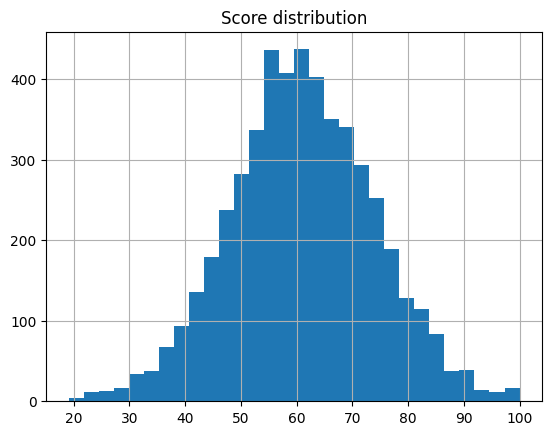

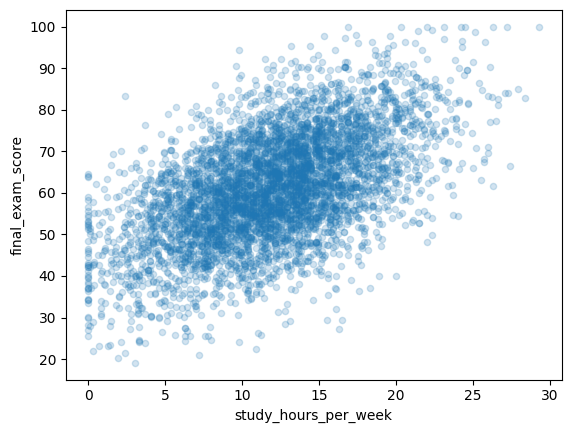

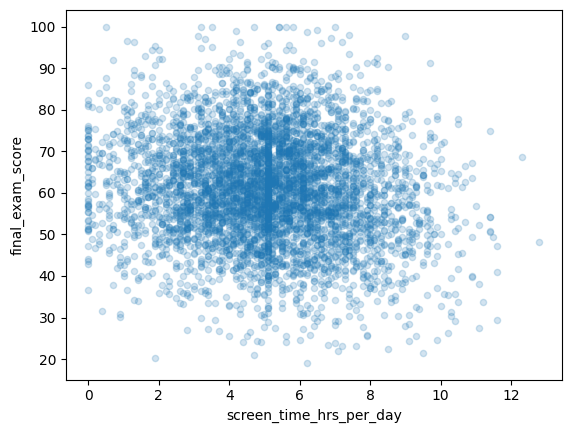

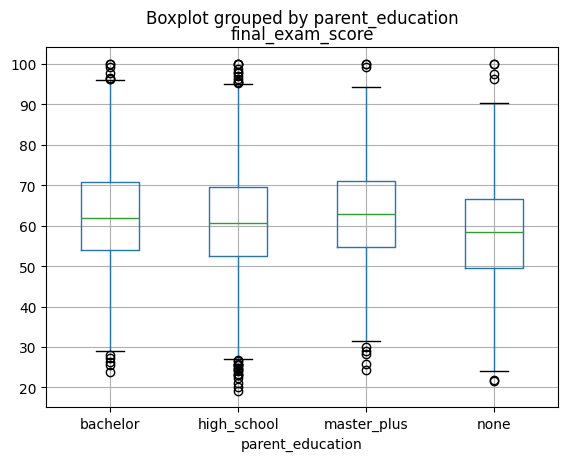

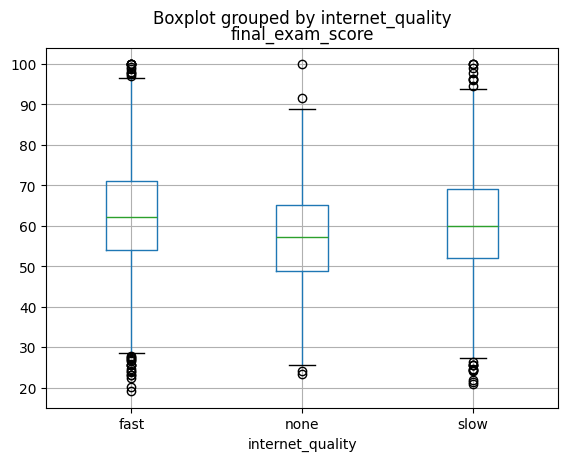

In [25]:
data_messy["final_exam_score"].hist(bins=30); plt.title("Score distribution"); plt.show()
data_messy.plot.scatter(x="study_hours_per_week", y="final_exam_score", alpha=0.2); plt.show()
data_messy.plot.scatter(x="screen_time_hrs_per_day", y="final_exam_score", alpha=0.2); plt.show()
data_messy.boxplot(column="final_exam_score", by="parent_education"); plt.show()
data_messy.boxplot(column="final_exam_score", by="internet_quality"); plt.show()

# Splitting both of our data sets and setting up MAE

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = data_messy.drop(columns=["student_id", "final_exam_score", "passed"])
X = pd.get_dummies(X, columns=["internet_quality","school_type","parent_education","favorite_color"])
y = data_messy["final_exam_score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dummy_regressor = DummyRegressor(strategy='mean').fit(X_train,y_train)
pred = dummy_regressor.predict(X_test)
print(mean_absolute_error(y_test, pred))
print(r2_score(y_test, pred))

10.257853149999999
-0.00021342649319922025


# Training and testing our multiple linear regression model

In [27]:
from sklearn.linear_model import LinearRegression

linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)
print(mean_absolute_error(y_test, linear_regressor.predict(X_test)))
print(r2_score(y_test, linear_regressor.predict(X_test)))

6.83824132533368
0.5652204358734927


# Training and testing our SVR model

In [28]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

svr_regressor = make_pipeline(StandardScaler(), SVR(C=100,kernel='rbf'))
svr_regressor.fit(X_train, y_train)
print(mean_absolute_error(y_test, svr_regressor.predict(X_test)))
print(r2_score(y_test, svr_regressor.predict(X_test)))


8.184355344829608
0.3757819372506823


# Traning and testing random forest regression model

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(n_estimators=300, random_state=42)
rf_regressor.fit(X_train, y_train)
print(mean_absolute_error(y_test, rf_regressor.predict(X_test)))
print(r2_score(y_test, rf_regressor.predict(X_test)))

7.189904666666665
0.5233707861884054


# Investigating data

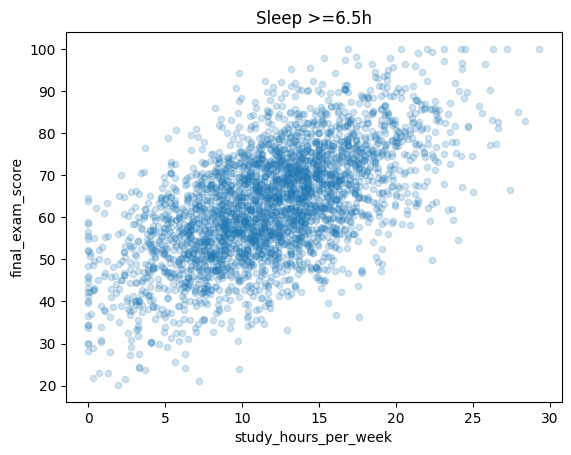

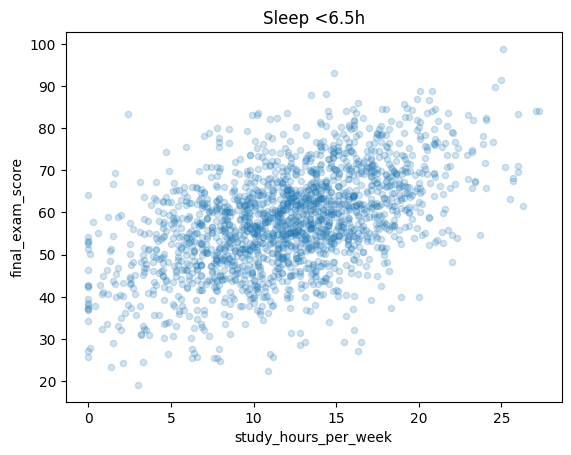

In [30]:
good_sleep = data_messy["sleep_hours_per_night"] >= 6.5
data_messy[good_sleep].plot.scatter(x="study_hours_per_week", y="final_exam_score", alpha=0.2, title="Sleep >=6.5h");
plt.show()
data_messy[~good_sleep].plot.scatter(x="study_hours_per_week", y="final_exam_score", alpha=0.2, title="Sleep <6.5h");
plt.show()

# Repeating expirment but with clean data

In [31]:
X_Clean = data_clean.drop(columns=["student_id", "final_exam_score", "passed"])
X_Clean = pd.get_dummies(X_Clean, columns=["internet_quality","school_type","parent_education","favorite_color"])
y_Clean = data_clean["final_exam_score"]
X_train_Clean, X_test_Clean, y_train_Clean, y_test_Clean = train_test_split(X_Clean, y_Clean, test_size=0.2, random_state=42)
## Linear regression
linear_regressor_Clean = LinearRegression()
linear_regressor_Clean.fit(X_train_Clean, y_train_Clean)
print(mean_absolute_error(y_test_Clean, linear_regressor_Clean.predict(X_test_Clean)))
print(r2_score(y_test_Clean, linear_regressor_Clean.predict(X_test_Clean)))

##SVR
svr_regressor_Clean = make_pipeline(StandardScaler(), SVR(C=100,kernel='rbf'))
svr_regressor_Clean.fit(X_train_Clean, y_train_Clean)
print(mean_absolute_error(y_test_Clean, svr_regressor_Clean.predict(X_test_Clean)))
print(r2_score(y_test_Clean, svr_regressor_Clean.predict(X_test_Clean)))

##Random forest regression
rf_regressor_Clean = RandomForestRegressor(n_estimators=300, random_state=42)
rf_regressor_Clean.fit(X_train_Clean, y_train_Clean)
print(mean_absolute_error(y_test_Clean, rf_regressor_Clean.predict(X_test_Clean)))
print(r2_score(y_test_Clean, rf_regressor_Clean.predict(X_test_Clean)))

6.626652473397472
0.5895328875831176
8.123280283617081
0.38556804805761946
6.796893000000002
0.5626196602729607


# Redoing expirment but with raw data

In [32]:
X_raw = data_raw.drop(columns=["student_id", "final_exam_score", "passed"])
X_raw = pd.get_dummies(X_raw, columns=["internet_quality","school_type","parent_education","favorite_color"])
X_raw = X_raw.fillna(-999)
y_raw = data_raw["final_exam_score"]
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)
##linear regression
linear_regressor_raw = LinearRegression()
linear_regressor_raw.fit(X_train_raw, y_train_raw)
print(mean_absolute_error(y_test_raw, linear_regressor_raw.predict(X_test_raw)))
print(r2_score(y_test_raw, linear_regressor_raw.predict(X_test_raw)))
##SVR
svr_regressor_raw = make_pipeline(StandardScaler(), SVR(C=100,kernel='rbf'))
svr_regressor_raw.fit(X_train_raw, y_train_raw)
print(mean_absolute_error(y_test_raw, svr_regressor_raw.predict(X_test_raw)))
print(r2_score(y_test_raw, svr_regressor_raw.predict(X_test_raw)))

##Random forest regression
rf_regressor_raw = RandomForestRegressor(n_estimators=300, random_state=42)
rf_regressor_raw.fit(X_train_raw, y_train_raw)
print(mean_absolute_error(y_test_raw, rf_regressor_raw.predict(X_test_raw)))
print(r2_score(y_test_raw, rf_regressor_raw.predict(X_test_raw)))


8.679413905473956
0.3185572235296801
8.890538181901267
0.29168212565812124
7.132149834983502
0.5632646464370874
